# Previous Material: Not Assigned

This notebook uses another textbook's chapter numbering. It is retained for review, not assigned reading for the current course. Its chapter, week, and examination labels are historical and do not define current requirements. Use the current course syllabus and its first-meeting notebook links.


# Chapter 19: Recovery System


## Core Question

After a crash, how can a DBMS preserve committed updates and remove the effects of
incomplete transactions?

Chapter 18 and Chapter 19 share one class meeting. The classroom core is limited to log
records, write-ahead logging, transaction status, and a small redo/undo case. Detailed
checkpoint algorithms, backup administration, ARIES, and production restore procedures
are extensions.


## Connection to Other Chapters

Chapter 17 defined atomicity and durability. Chapter 18 explained how transactions may
wait or be rolled back during concurrent execution. This chapter introduces the log
evidence needed to recover after an abort or system crash.


## Prerequisites

You should be able to follow transaction events in order, distinguish `COMMIT` from
`ROLLBACK`, and distinguish a memory buffer from persistent storage.


## Learning Objectives

After completing the classroom core, you should be able to:

1. Distinguish a transaction error, a system crash, and storage loss.
2. Interpret start, update, commit, and abort log records.
3. Explain the two ordering requirements of write-ahead logging.
4. Identify committed and incomplete transactions in a small stable log.
5. Apply new values for redo and old values for undo in a supplied case.
6. State the limits of the supplied recovery simulator.


## Teaching Summary

| Classroom topic | Worked evidence | Evidence to retain |
|---|---|---|
| Failure and available evidence | Transaction error versus crash | Classification with reason |
| Log records | Old and new values | One redo and one undo decision |
| Write-ahead logging | Valid and invalid event order | Corrected WAL timeline |
| Simplified recovery | One committed and one incomplete transaction | Redo/undo table and final state |


## 1. Failure and Storage Assumptions

Different failures require different evidence:

| Failure | Example | Main response |
|---|---|---|
| Transaction error | Invalid input or a failed constraint | Abort that transaction |
| System transaction error | Deadlock victim | Roll back; retry only when safe |
| System crash | Process, OS, or power failure while persistent storage remains readable | Use the stable log for restart recovery |
| Storage loss | Unreadable or lost database blocks | Restore a base copy, then use retained log data |

The classroom recovery example assumes a fail-stop system crash: volatile memory is lost,
but the persistent database and stable log remain readable. This assumption does not
cover every hardware failure.


### Small Example: Separate lost memory from lost persistent data

A restart-recovery example needs an explicit failure assumption. If volatile buffers are lost but the database and log remain readable, the stable log can support recovery. Loss of the persistent database needs additional retained evidence.

The following data are artificial teaching inputs, not student records.

**Input: places**

| location | example content |
| --- | --- |
| memory buffer | recent unflushed changes |
| database storage | written data pages |
| stable log | forced log records |

**Predict before checking.** In a fail-stop system crash with readable storage, which of these three sources is lost? What changes when database storage is unreadable?


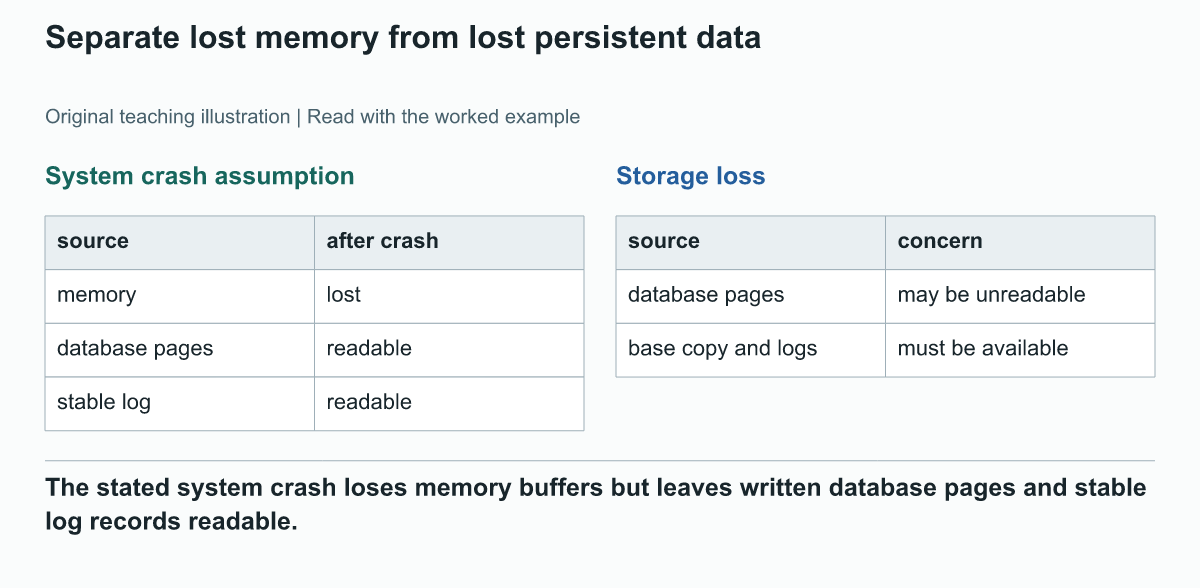


**Read the result.** The stated system crash loses memory buffers but leaves written database pages and stable log records readable. Storage loss removes that assumption; a usable base copy and retained logs may be needed. A readable log is not automatically a complete copy of the database.

**Try a change.** Classify a failed constraint and a deadlock victim separately from storage loss. State which transaction effects need removal.

**Check your reasoning.** Name what survives before choosing a recovery explanation. Do not treat all failures as the same restart case.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Predict Before Checking

Classify each event:

1. The application rolls back because an account identifier does not exist.
2. The DBMS process restarts and the persistent database remains readable.
3. A storage device loses database blocks.
4. The DBMS selects T7 as a deadlock victim.


### Check Criteria

The classifications are transaction error, system crash, storage loss, and system
transaction error. Each answer must state what persistent evidence remains available.


## 2. Log Records

A log records transaction events in order. A basic example is:

```text
<T0 start>
<T0, A, 1000, 950>
<T0, B, 2000, 2050>
<T0 commit>
```

An update record `<Ti, X, old, new>` identifies the transaction and item. The old value
supports undo; the new value supports redo.


### Read the old and new values from an update record

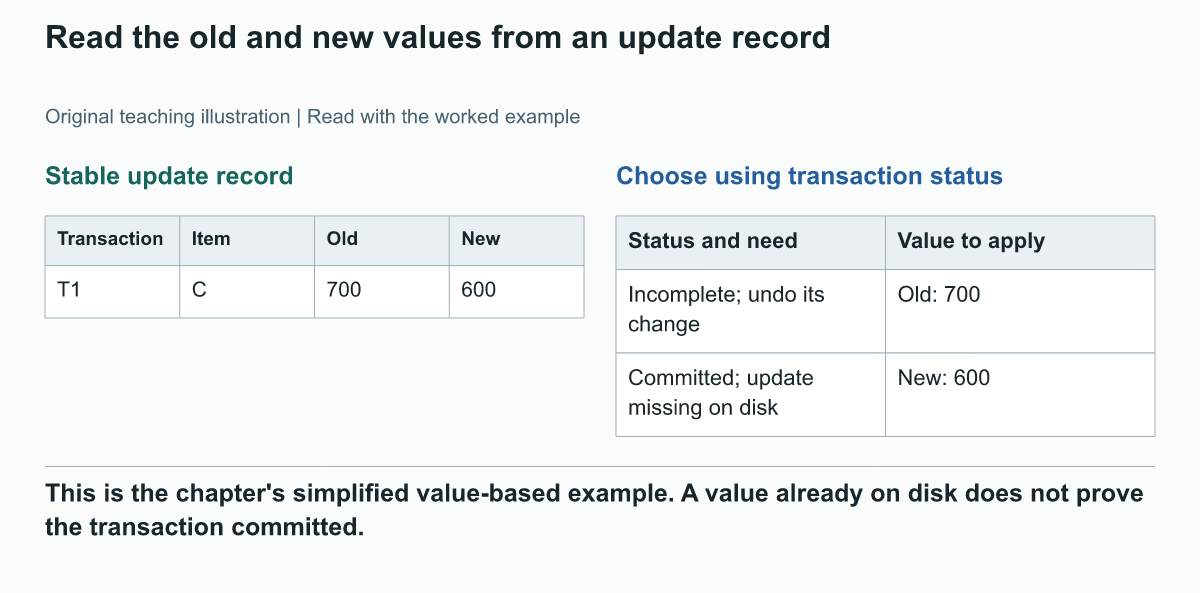

This is the chapter's simplified value-based example. A value already on disk does not prove the transaction committed.


### Small Example: Determine commit status from the stable log

A data value already on disk does not prove its transaction committed. Inspect start, update, and commit records in the stable log before choosing what must survive recovery.

The following data are artificial teaching inputs, not student records.

**Input: log**

| position | record |
| --- | --- |
| 1 | T1 start |
| 2 | T1: A, old 10, new 8 |
| 3 | T1 commit |
| 4 | T2 start |
| 5 | T2: B, old 7, new 4 |

**Predict before checking.** If disk already contains A=8 and B=4, which transaction is still incomplete at the crash?


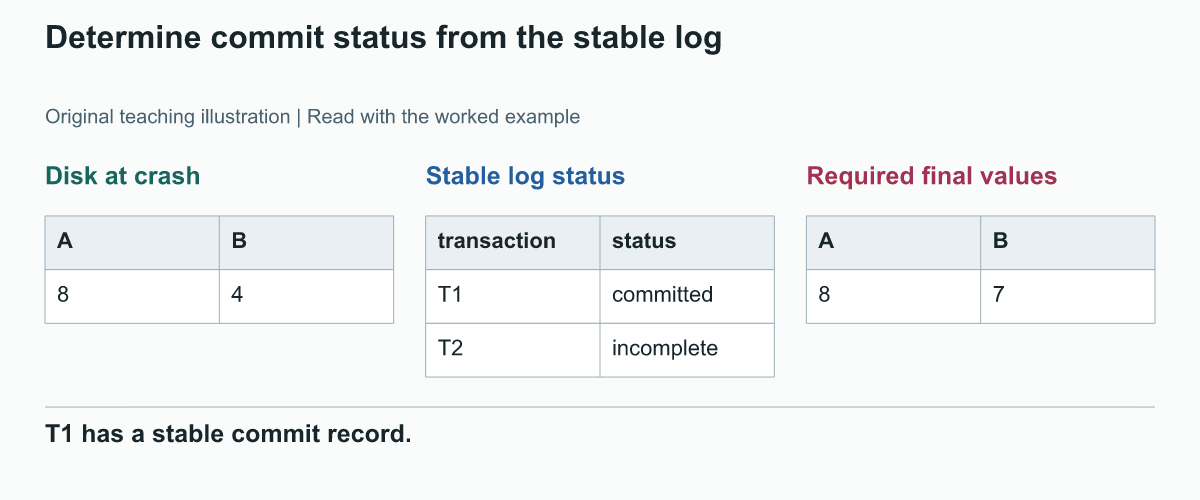


**Read the result.** T1 has a stable commit record. T2 has only start and update records, so it remains incomplete in this case. The final state must retain T1's A=8 and remove T2's B=4 effect, restoring B=7 under the simple old/new-value model.

**Try a change.** Add a stable T2 commit record before the crash. Explain how the required final value of B changes.

**Check your reasoning.** Use log status and old/new fields together. Do not use the current disk value as a substitute for commit evidence.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Worked Example

For `<T1, C, 700, 600>`:

- if T1 is incomplete and disk contains 600, undo restores 700;
- if T1 committed and disk still contains 700, redo writes 600.

Recovery applies values recorded in the log. It does not rerun arbitrary application
code, which could read different data or repeat an external side effect.


### Practice

Given `<T5, inventory, 12, 9>`, identify the value used when T5 is incomplete and the
value used when T5 committed but the data page was not written.


### Check Criteria

Undo uses 12; redo uses 9. The explanation must include transaction status.


## 3. Write-Ahead Logging

Log records may first enter a memory buffer. A crash can lose records that have not been
forced to stable storage. Write-ahead logging (WAL) therefore requires two important
orders:

1. Before a modified data page is written to persistent storage, the log information
   needed to undo or redo that update must already be stable.
2. Before the DBMS acknowledges commit, the transaction's earlier log records and commit
   record must be stable.

WAL means log evidence precedes the protected data write or commit acknowledgement. It
does not require every committed data page to be written before commit.


### Persist the log before the protected action

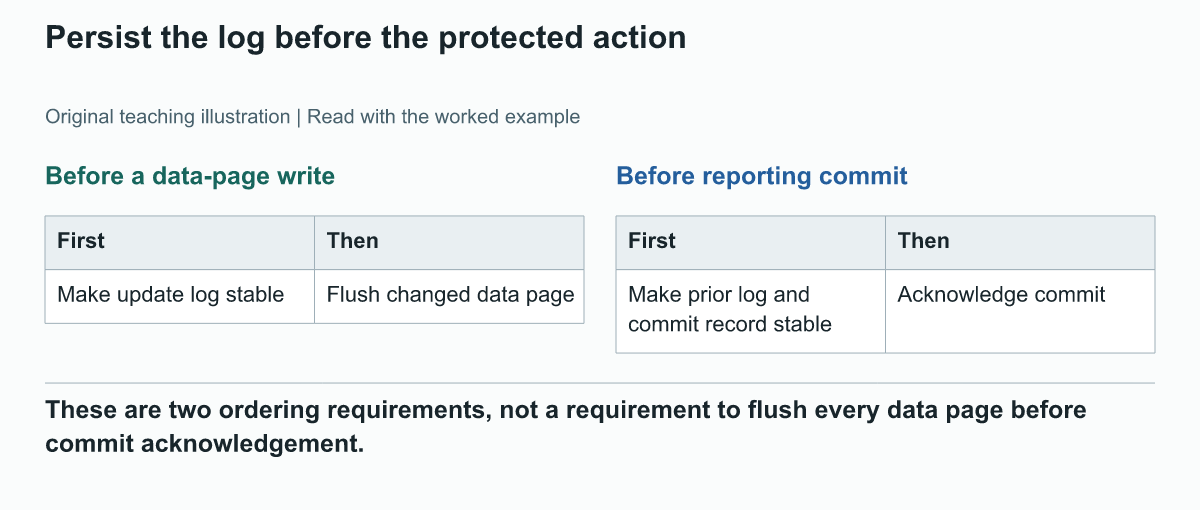

These are two ordering requirements, not a requirement to flush every data page before commit acknowledgement.


### Worked Timeline

```text
1. Create <T0, A, 1000, 950> in the log buffer
2. Force the update log record
3. Flush the data page containing A
4. Create <T0 commit>
5. Force the log through the commit record
6. Acknowledge commit
```

Flushing the data page before Step 2 violates the data-write ordering rule. Acknowledging
commit before Step 5 violates the commit ordering rule.


### Practice

Correct this sequence:

```text
create update log -> flush data -> create commit log -> acknowledge commit -> force log
```


### Check Criteria

At minimum, force the update log before flushing the data page and force through the
commit record before acknowledging commit.


## 4. Simplified Redo and Undo

Use the supplied log and crash state:

```text
Disk at crash: A=950, B=2000, C=600

<T0 start>
<T0, A, 1000, 950>
<T0, B, 2000, 2050>
<T0 commit>
<T1 start>
<T1, C, 700, 600>
-- crash: no T1 commit or abort
```

T0 is committed, so its updates must be present after recovery. T1 is incomplete, so its
update must not remain.


### Restore logged history, then undo incomplete work

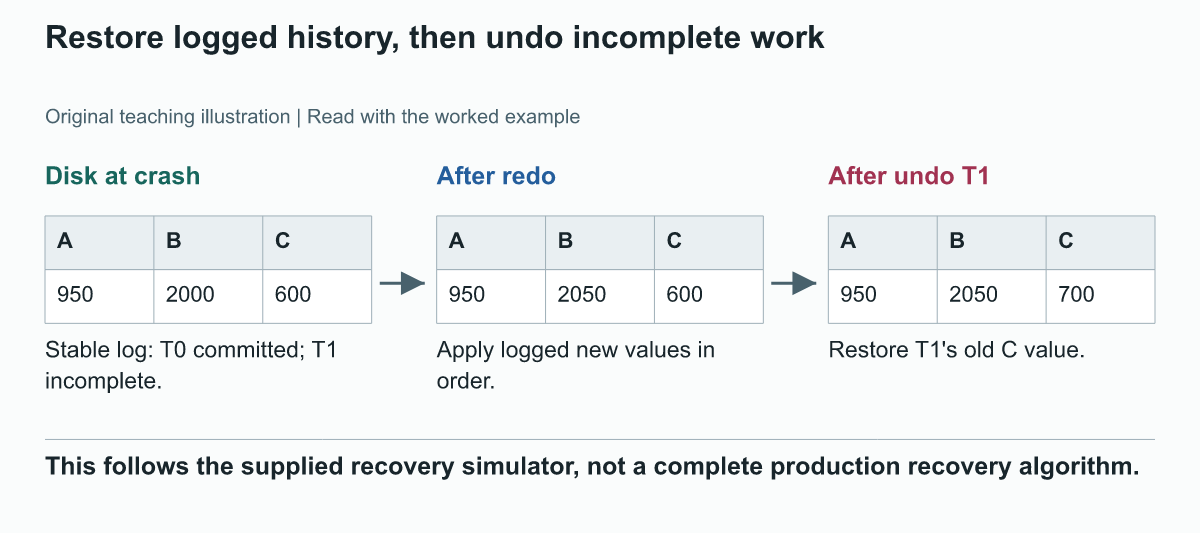

This follows the supplied recovery simulator, not a complete production recovery algorithm.


### Predict Before Running

Create a table with columns for log record, transaction status, redo action, and undo
action. Predict the final values before using the simulator.


### Worked Interpretation

Redo restores the logged history: A becomes 950, B becomes 2050, and C becomes 600.
T1 remains incomplete, so undo restores C to 700. The final database is:

```text
A=950, B=2050, C=700
```


### Additional Practice

Add the stable records:

```text
<T2 start>
<T2, A, 950, 900>
<T2 commit>
```

The final A is 900 because T2 committed. Transaction status comes from the stable log,
not from a value that happens to be present on disk at crash time.


## 5. Executable Activities

First calculate the example by hand, then run:

```powershell
Run the embedded recovery-simulator cell below.
```

Check these observations:

```text
incomplete_after_redo = [T1]
redo: T0.A=950, T0.B=2050, T1.C=600
undo: T1.C=700
final_database = {A:950, B:2050, C:700}
```

Then run the WAL checker:

```powershell
Run the embedded write-ahead logging checker below.
```

Expected results:

- `valid` passes;
- `invalid_data_before_log` violates the data-write order;
- `invalid_commit_before_force` acknowledges commit before the commit record is stable.

The programs use simplified, explicit rules. They do not implement page LSNs, dirty-page
tables, fuzzy checkpoints, logical undo, group commit, partial disk writes, parallel
recovery, or a production DBMS storage manager.


## Extensions: Checkpoints and Backups

A checkpoint can reduce the amount of log examined during restart, but active
transactions may still require earlier records. A checkpoint is not a backup.

A backup provides a base copy after storage loss. Retained post-backup logs may move that
copy forward to a later consistent point. A backup without needed logs may lose later
committed work; logs without a readable base copy may be insufficient to reconstruct the
database.

Detailed checkpoint algorithms, ARIES, point-in-time recovery commands, remote replicas,
and production restore administration are after-class extensions and are not part of the
Exam 3 classroom core.


## Common Errors

1. Treating a system crash and storage loss as the same failure.
2. Assuming that commit means every data page is already persistent.
3. Reversing WAL and writing the data page before its log evidence.
4. Ignoring an incomplete transaction whose update already reached disk.
5. Deciding commit status from crash-time data values rather than the stable log.
6. Treating a checkpoint as a backup.
7. Treating a simulator result as a production recovery test.


## Discussion and Individual Evidence

Discuss this case: an API reports payment success before the commit record becomes stable,
and the server then crashes. Explain which durability promise was broken and which WAL
ordering rule should have prevented it.

Retain:

1. Four failure classifications with reasons.
2. One old-value undo and one new-value redo explanation.
3. A corrected WAL timeline.
4. The hand-calculated redo/undo table and final state.
5. Output from both supplied programs.
6. One explicit limitation that prevents generalizing the model to production DBMSs.


## Chapter Summary

Recovery depends on evidence written before failure. Old values support undo, new values
support redo, and a stable commit record separates committed from incomplete work. WAL
requires recovery information to become stable before the protected data write and
before commit acknowledgement. Checkpoints, backups, and production recovery algorithms
remain extensions.


## After-Class Continuation

Add one committed transaction and one incomplete transaction to the embedded recovery case.
Predict the final database, then run the simulator. Students interested in operations may
study a server DBMS's backup and point-in-time recovery procedure as an extension.


## Why This Chapter Uses a Simulation

SQLite can create tables and execute transactions, but it does not expose a server lock manager, wait-for graph, write-ahead log, or restart-recovery procedure for direct classroom inspection. This notebook therefore uses a small verified Python simulation for the chapter mechanism. Treat the result as an instructional model, not as observed SQLite server behavior.


## Executable Notebook Demonstrations

The source code and data are embedded in this notebook. Each cell creates a temporary directory, runs the demonstration, and removes the temporary files automatically.


### Recovery simulator


In [1]:
import subprocess
import sys
import tempfile
from pathlib import Path

SCRIPT_SOURCE = '''"""Simulate basic repeating-history recovery and backup-plus-log restore."""

from __future__ import annotations

import argparse
import json
from copy import deepcopy
from pathlib import Path
from typing import Any


def records_from_checkpoint(case: dict[str, Any]) -> list[dict[str, Any]]:
    checkpoint_lsn = case["checkpoint_lsn"]
    records = [record for record in case["log"] if record["lsn"] >= checkpoint_lsn]
    if not records or records[0]["type"] != "CHECKPOINT":
        raise ValueError("checkpoint_lsn must identify the first CHECKPOINT record")
    return records


def restart_recovery(case: dict[str, Any]) -> dict[str, Any]:
    records = records_from_checkpoint(case)
    database = deepcopy(case["disk_at_crash"])
    undo_list = set(records[0].get("active", []))
    redo_trace: list[str] = []

    for record in records[1:]:
        record_type = record["type"]
        transaction = record.get("transaction")
        if record_type == "START":
            undo_list.add(transaction)
        elif record_type == "UPDATE":
            database[record["item"]] = record["new"]
            redo_trace.append(
                f"REDO LSN {record['lsn']} {transaction} {record['item']}={record['new']}"
            )
        elif record_type in {"COMMIT", "ABORT"}:
            undo_list.discard(transaction)

    incomplete_after_redo = sorted(undo_list)
    undo_trace: list[str] = []
    compensation_records: list[dict[str, Any]] = []
    for record in reversed(records[1:]):
        transaction = record.get("transaction")
        if transaction not in undo_list:
            continue
        if record["type"] == "UPDATE":
            database[record["item"]] = record["old"]
            undo_trace.append(
                f"UNDO LSN {record['lsn']} {transaction} {record['item']}={record['old']}"
            )
            compensation_records.append(
                {
                    "type": "REDO_ONLY",
                    "transaction": transaction,
                    "item": record["item"],
                    "value": record["old"],
                }
            )
        elif record["type"] == "START":
            compensation_records.append({"type": "ABORT", "transaction": transaction})
            undo_list.remove(transaction)
        if not undo_list:
            break

    return {
        "redo_trace": redo_trace,
        "incomplete_after_redo": incomplete_after_redo,
        "undo_trace": undo_trace,
        "generated_records": compensation_records,
        "final_database": database,
    }


def restore_from_backup(case: dict[str, Any]) -> dict[str, int]:
    database = deepcopy(case["archival_backup"])
    committed: set[str] = {
        record["transaction"]
        for record in case["committed_log_after_backup"]
        if record["type"] == "COMMIT"
    }
    for record in case["committed_log_after_backup"]:
        if record["type"] == "UPDATE" and record["transaction"] in committed:
            database[record["item"]] = record["new"]
    return database


def analyze(case: dict[str, Any]) -> dict[str, Any]:
    return {
        "restart_recovery": restart_recovery(case),
        "backup_plus_committed_log": restore_from_backup(case),
    }


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "case_file",
        nargs="?",
        type=Path,
        default=Path(__file__).with_name("recovery_case.json"),
    )
    args = parser.parse_args()
    case = json.loads(args.case_file.read_text(encoding="utf-8"))
    print(json.dumps(analyze(case), ensure_ascii=False, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()
'''

DATA_1_SOURCE = """{
  "checkpoint_lsn": 1,
  "disk_at_crash": {
    "A": 950,
    "B": 2000,
    "C": 600
  },
  "log": [
    {"lsn": 1, "type": "CHECKPOINT", "active": []},
    {"lsn": 2, "type": "START", "transaction": "T0"},
    {"lsn": 3, "type": "UPDATE", "transaction": "T0", "item": "A", "old": 1000, "new": 950},
    {"lsn": 4, "type": "UPDATE", "transaction": "T0", "item": "B", "old": 2000, "new": 2050},
    {"lsn": 5, "type": "COMMIT", "transaction": "T0"},
    {"lsn": 6, "type": "START", "transaction": "T1"},
    {"lsn": 7, "type": "UPDATE", "transaction": "T1", "item": "C", "old": 700, "new": 600}
  ],
  "archival_backup": {
    "A": 1000,
    "B": 2000,
    "C": 700
  },
  "committed_log_after_backup": [
    {"lsn": 2, "type": "START", "transaction": "T0"},
    {"lsn": 3, "type": "UPDATE", "transaction": "T0", "item": "A", "old": 1000, "new": 950},
    {"lsn": 4, "type": "UPDATE", "transaction": "T0", "item": "B", "old": 2000, "new": 2050},
    {"lsn": 5, "type": "COMMIT", "transaction": "T0"}
  ]
}
"""

embedded_files = {
    'recovery_simulator.py': SCRIPT_SOURCE,
    'recovery_case.json': DATA_1_SOURCE,
}
with tempfile.TemporaryDirectory(prefix="database_notebook_") as temp_directory:
    temp_path = Path(temp_directory)
    for filename, content in embedded_files.items():
        (temp_path / filename).write_text(content, encoding="utf-8")
    command = [sys.executable, str(temp_path / 'recovery_simulator.py')] + ['recovery_case.json']
    completed = subprocess.run(command, cwd=temp_path, text=True, capture_output=True, check=False)
    print(completed.stdout, end="")
    if completed.stderr:
        print(completed.stderr, end="", file=sys.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Embedded program failed with exit code {completed.returncode}")


{
  "backup_plus_committed_log": {
    "A": 950,
    "B": 2050,
    "C": 700
  },
  "restart_recovery": {
    "final_database": {
      "A": 950,
      "B": 2050,
      "C": 700
    },
    "generated_records": [
      {
        "item": "C",
        "transaction": "T1",
        "type": "REDO_ONLY",
        "value": 700
      },
      {
        "transaction": "T1",
        "type": "ABORT"
      }
    ],
    "incomplete_after_redo": [
      "T1"
    ],
    "redo_trace": [
      "REDO LSN 3 T0 A=950",
      "REDO LSN 4 T0 B=2050",
      "REDO LSN 7 T1 C=600"
    ],
    "undo_trace": [
      "UNDO LSN 7 T1 C=700"
    ]
  }
}


### Write-ahead logging checker


In [2]:
import subprocess
import sys
import tempfile
from pathlib import Path

SCRIPT_SOURCE = '''"""Check small event timelines against core write-ahead logging requirements."""

from __future__ import annotations

import argparse
import json
from collections import defaultdict
from pathlib import Path
from typing import Any


def check(events: list[dict[str, Any]]) -> dict[str, Any]:
    forced_through = 0
    update_lsns_by_item: dict[str, list[int]] = defaultdict(list)
    transaction_lsns: dict[str, list[int]] = defaultdict(list)
    commit_lsn: dict[str, int] = {}
    violations: list[str] = []

    for position, event in enumerate(events, start=1):
        action = event["action"]
        if action == "CREATE_UPDATE_LOG":
            update_lsns_by_item[event["item"]].append(event["lsn"])
            transaction_lsns[event["transaction"]].append(event["lsn"])
        elif action == "CREATE_COMMIT_LOG":
            transaction_lsns[event["transaction"]].append(event["lsn"])
            commit_lsn[event["transaction"]] = event["lsn"]
        elif action == "FORCE_LOG":
            forced_through = max(forced_through, event["through_lsn"])
        elif action == "FLUSH_DATA":
            needed = update_lsns_by_item[event["item"]]
            if needed and max(needed) > forced_through:
                violations.append(
                    f"event {position}: data {event['item']} flushed before update log"
                )
        elif action == "ACK_COMMIT":
            transaction = event["transaction"]
            needed = transaction_lsns[transaction]
            if transaction not in commit_lsn or not needed or max(needed) > forced_through:
                violations.append(
                    f"event {position}: {transaction} acknowledged before commit log force"
                )
        else:
            raise ValueError(f"Unknown action: {action}")

    return {"valid": not violations, "violations": violations}


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "scenario_file",
        nargs="?",
        type=Path,
        default=Path(__file__).with_name("wal_scenarios.json"),
    )
    args = parser.parse_args()
    scenarios = json.loads(args.scenario_file.read_text(encoding="utf-8"))
    for name, events in scenarios.items():
        print(f"[{name}]")
        print(json.dumps(check(events), ensure_ascii=False, sort_keys=True))


if __name__ == "__main__":
    main()
'''

DATA_1_SOURCE = """{
  "valid": [
    {"action": "CREATE_UPDATE_LOG", "lsn": 1, "transaction": "T0", "item": "A"},
    {"action": "FORCE_LOG", "through_lsn": 1},
    {"action": "FLUSH_DATA", "item": "A"},
    {"action": "CREATE_COMMIT_LOG", "lsn": 2, "transaction": "T0"},
    {"action": "FORCE_LOG", "through_lsn": 2},
    {"action": "ACK_COMMIT", "transaction": "T0"}
  ],
  "invalid_data_before_log": [
    {"action": "CREATE_UPDATE_LOG", "lsn": 1, "transaction": "T0", "item": "A"},
    {"action": "FLUSH_DATA", "item": "A"},
    {"action": "FORCE_LOG", "through_lsn": 1}
  ],
  "invalid_commit_before_force": [
    {"action": "CREATE_UPDATE_LOG", "lsn": 1, "transaction": "T0", "item": "A"},
    {"action": "FORCE_LOG", "through_lsn": 1},
    {"action": "CREATE_COMMIT_LOG", "lsn": 2, "transaction": "T0"},
    {"action": "ACK_COMMIT", "transaction": "T0"},
    {"action": "FORCE_LOG", "through_lsn": 2}
  ]
}
"""

embedded_files = {
    'wal_checker.py': SCRIPT_SOURCE,
    'wal_scenarios.json': DATA_1_SOURCE,
}
with tempfile.TemporaryDirectory(prefix="database_notebook_") as temp_directory:
    temp_path = Path(temp_directory)
    for filename, content in embedded_files.items():
        (temp_path / filename).write_text(content, encoding="utf-8")
    command = [sys.executable, str(temp_path / 'wal_checker.py')] + ['wal_scenarios.json']
    completed = subprocess.run(command, cwd=temp_path, text=True, capture_output=True, check=False)
    print(completed.stdout, end="")
    if completed.stderr:
        print(completed.stderr, end="", file=sys.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Embedded program failed with exit code {completed.returncode}")


[valid]
{"valid": true, "violations": []}
[invalid_data_before_log]
{"valid": false, "violations": ["event 2: data A flushed before update log"]}
[invalid_commit_before_force]
{"valid": false, "violations": ["event 4: T0 acknowledged before commit log force"]}
